  # Clasificación Binaria de Alzheimer con ResNet 3D

  Entrenamiento y evaluación comparativa de **3D-ResNet18** y **3D-ResNet34**
  para la clasificación binaria entre sujetos *Non-Demented* (CDR = 0) y *Very Mild Dementia* (CDR = 0.5), a partir de volúmenes MRI del dataset OASIS-1. El conjunto de entrenamiento incorpora volúmenes sintéticos generados con HA-GAN para balancear la clase minoritaria. Los modelos se evalúan sobre sujetos reales exclusivamente (conjuntos de validación y prueba), garantizando comparabilidad con los modelos 2D bajo las mismas condiciones experimentales.

 ## 0. Configuración del Entorno

 Se detecta si el notebook corre en Google Colab para montar el Drive e instalar las dependencias necesarias, si se requiere. . Las librerías principales son nibabel, scipy  y scikit-learn

In [ ]:
import subprocess, sys, os

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q',
          'nibabel', 'scipy', 'scikit-learn'],
        check=True
    )

print(f'IN_COLAB: {IN_COLAB}')

Mounted at /content/drive
IN_COLAB: True


  Se importan todos los módulos necesarios.

In [ ]:
import os, sys, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from scipy.ndimage import zoom
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from sklearn.metrics import (
    accuracy_score,
    f1_score, balanced_accuracy_score,
    recall_score, precision_score,
    roc_auc_score,
    matthews_corrcoef, confusion_matrix
)

warnings.filterwarnings('ignore')

try:
    display
except NameError:
    def display(*args, **kwargs):
        for a in args:
            print(a)

print('Importaciones completas.')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA disponible: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU  : {torch.cuda.get_device_name(0)}')
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM : {mem:.1f} GB')


Importaciones completas.
PyTorch : 2.10.0+cu128
CUDA disponible: True
GPU  : Tesla T4
VRAM : 15.6 GB



  Se definen todas las rutas del proyecto, los hiperparámetros de entrenamiento y las
  semillas de aleatoriedad. La partición estratificada ya fue generada por el notebook de aumentación 3D splits_subjects.csv y compartida con el modelo 2D, garantizando que ambos enfoques se evalúan sobre exactamente los mismos sujetos.

  Los hiperparámetros más relevantes son:
  - **`TARGET_SHAPE = (64, 64, 64)`**: resolución de entrada para los modelos 3D
  - **`BATCH_SIZE = 4`**
  - **`PATIENCE_ES = 10`**: *early stopping* sobre el F1-macro de validación, para evitar sobreajuste con el dataset
  - **`DISPLAY_KEYS`**: lista de métricas diagnósticas como de costo computacional

In [ ]:
#  Rutas
BASE_DIR    = '/content/drive/MyDrive/Proyecto imagenes y vision'
AUG_CSV     = os.path.join(BASE_DIR, 'OASIS_Augmentation_3D', 'dataset_augmented.csv')
RESULTS_DIR = os.path.join(BASE_DIR, 'Models', 'Modelo_3D_results')
CKPT_DIR    = os.path.join(RESULTS_DIR, 'checkpoints')

# Prefijo incorrecto en las rutas del CSV ( la carpeta antes se llamaba OASIS_Augmentation), Se corrige en memoria al cargar el CSV
CSV_PATH_OLD_PREFIX = os.path.join(BASE_DIR, 'OASIS_Augmentation')
CSV_PATH_NEW_PREFIX = os.path.join(BASE_DIR, 'OASIS_Augmentation_3D')

for d in [RESULTS_DIR, CKPT_DIR]:
    os.makedirs(d, exist_ok=True)

#  Hiperparámetros
TARGET_SHAPE  = (64, 64, 64)
BATCH_SIZE    = 4
MAX_EPOCHS    = 50
LR            = 1e-4
WEIGHT_DECAY  = 1e-4
PATIENCE_ES   = 10
PATIENCE_SCH  = 5
RANDOM_SEED   = 42

THRESHOLD_GRID = np.arange(0.10, 0.91, 0.05)

#  Reproducibilidad
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

g_seed = torch.Generator()
g_seed.manual_seed(RANDOM_SEED)

def seed_worker(worker_id):
    worker_seed = RANDOM_SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

DISPLAY_KEYS = [
    ('f1_macro',          'F1-macro'),
    ('balanced_acc',      'Balanced Acc'),
    ('recall_vmd',        'Recall VMD'),
    ('specificity',       'Specificity'),
    ('precision_vmd',     'Precision VMD'),
    ('roc_auc',           'ROC-AUC'),
    ('mcc',               'MCC'),
    ('accuracy',          'Accuracy'),
    ('optimal_threshold', 'Umbral optimo'),
    ('n_params_M',        'Params (M)'),
    ('total_time_min',    'T. total (min)'),
    ('mean_epoch_time_s', 'T. epoca (s)'),
    ('peak_gpu_mem_gb',   'Pico GPU (GB)'),
]
COST_KEYS = {'n_params_M', 'total_time_min', 'mean_epoch_time_s', 'peak_gpu_mem_gb'}

print(f'Device       : {device}')
print(f'TARGET_SHAPE : {TARGET_SHAPE}')
print(f'BATCH_SIZE   : {BATCH_SIZE}')
print(f'AUG_CSV      : {AUG_CSV}')
print(f'RESULTS_DIR  : {RESULTS_DIR}')
print(f'Fix rutas CSV: {CSV_PATH_OLD_PREFIX} → {CSV_PATH_NEW_PREFIX}')

Device       : cuda
TARGET_SHAPE : (64, 64, 64)
BATCH_SIZE   : 4
AUG_CSV      : /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_Augmentation_3D/dataset_augmented.csv
RESULTS_DIR  : /content/drive/MyDrive/Proyecto imagenes y vision/Models/Modelo_3D_results
Fix rutas CSV: /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_Augmentation → /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_Augmentation_3D


In [ ]:
df_aug = pd.read_csv(AUG_CSV)

# Actualizaciones de rutas: el CSV fue generado cuando la carpeta se llamaba OASIS_Augmentation y ahora se llama OASIS_Augmentation_3D
n_fixed = df_aug['file_path'].str.contains(CSV_PATH_OLD_PREFIX, regex=False).sum()
if n_fixed > 0:
    df_aug['file_path'] = df_aug['file_path'].str.replace(
        CSV_PATH_OLD_PREFIX, CSV_PATH_NEW_PREFIX, regex=False
    )
    print(f'Fix aplicado: {n_fixed} rutas actualizadas '
          f'(OASIS_Augmentation → OASIS_Augmentation_3D)')
else:
    print('Rutas del CSV ya son correctas (no se requiere fix).')

print(f'\nTotal de filas: {len(df_aug)}')
print(f'\n=== Distribución por split / label / tipo ===')
summary = df_aug.groupby(['split', 'label', 'tipo']).size().unstack(fill_value=0)
print(summary.to_string())

print(f'\n=== Balance de clases por split ===')
balance = df_aug.groupby(['split', 'label']).size().unstack(fill_value=0)
balance['ratio_sano:vmd'] = (balance.get('sano', 0) / balance.get('vmd', 1)).round(2)
print(balance.to_string())

assert df_aug.query("split=='val'  and tipo=='synthetic'").empty, \
    'ERROR: val contiene sintéticos.'
assert df_aug.query("split=='test' and tipo=='synthetic'").empty, \
    'ERROR: test contiene sintéticos.'

if 'subject_base' in df_aug.columns:
    overlap = (df_aug.groupby('subject_base')['split']
                     .nunique()
                     .loc[lambda s: s > 1])
    assert overlap.empty, \
        f'ERROR: {len(overlap)} sujeto(s) en más de un split.'
    print('\nVerificacion: ningún sujeto se repite entre splits. OK')

print('Verificacion: val y test no contienen sintéticos. OK')

Fix aplicado: 94 rutas actualizadas (OASIS_Augmentation → OASIS_Augmentation_3D)

Total de filas: 250

=== Distribución por split / label / tipo ===
tipo         real  synthetic
split label                 
test  sano     21          0
      vmd      10          0
train sano     94          0
      vmd      49         45
val   sano     20          0
      vmd      11          0

=== Balance de clases por split ===
label  sano  vmd  ratio_sano:vmd
split                           
test     21   10            2.10
train    94   94            1.00
val      20   11            1.82

Verificacion: ningún sujeto se repite entre splits. OK
Verificacion: val y test no contienen sintéticos. OK


  ## 1. Exploración del Dataset

  Se carga el archivo `dataset_augmented.csv` generado por el notebook de
  aumentación HA-GAN. Este CSV contiene una fila por volumen (real o sintético), con las columnas `split`, `label`, `tipo` y `file_path`. El conjunto de entrenamiento está balanceado mediante la generación de 45 volúmenes sintéticos VMD, mientras que los conjuntos de validación y prueba contienen únicamente sujetos reales, respetando la distribución natural del dataset OASIS-1.

In [ ]:

print(f'Total de filas: {len(df_aug)}')
print(f'\n=== Distribución por split / label / tipo ===')
summary = df_aug.groupby(['split', 'label', 'tipo']).size().unstack(fill_value=0)
print(summary.to_string())

print(f'\n=== Balance de clases por split ===')
balance = df_aug.groupby(['split', 'label']).size().unstack(fill_value=0)
balance['ratio_sano:vmd'] = (balance.get('sano', 0) / balance.get('vmd', 1)).round(2)
print(balance.to_string())

print(f'\n=== Extensiones de archivo en el CSV ===')
exts = df_aug['file_path'].str.extract(r'(\.[^./]+(?:\.[^./]+)?)$')[0].value_counts()
print(exts.to_string())

assert '.npy'   in exts.index, 'AVISO: no se encontraron archivos .npy (VMD reales)'
assert '.nii.gz' in exts.index, 'AVISO: no se encontraron archivos .nii.gz (sintéticos)'
print('\nFormatos OK: .hdr (sanos reales) | .npy (VMD reales) | .nii.gz (sintéticos)')

Total de filas: 250

=== Distribución por split / label / tipo ===
tipo         real  synthetic
split label                 
test  sano     21          0
      vmd      10          0
train sano     94          0
      vmd      49         45
val   sano     20          0
      vmd      11          0

=== Balance de clases por split ===
label  sano  vmd  ratio_sano:vmd
split                           
test     21   10            2.10
train    94   94            1.00
val      20   11            1.82

=== Extensiones de archivo en el CSV ===
0
.hdr       156
.npy        49
.nii.gz     45

Formatos OK: .hdr (sanos reales) | .npy (VMD reales) | .nii.gz (sintéticos)


  ## 2. Preprocesamiento y Clase Dataset

  La función `load_and_preprocess` aplica un pipeline uniforme a todos los
  volúmenes,
  independientemente de si son reales (`.hdr`, 176 × 208 × 176 vóxeles) o
  sintéticos
  (`.nii.gz`, 256 × 256 × 256 vóxeles en escala [0, 255]):

  1. **Carga con nibabel** y eliminación de dimensiones extra con `np.squeeze`.
  2. **Normalización z-score por instancia** sobre los vóxeles de tejido: para los volúmenes reales el fondo es exactamente 0 (máscara OASIS), mientras que para los sintéticos HA-GAN se considera tejido todo vóxel con intensidad > 10 (umbral coherente con el filtro aplicado en la generación). Este paso elimina la diferencia de escala entre ambos tipos antes de que los datos entren al modelo.
  3. **Redimensionamiento trilineal** a la forma
  objetivo `(64, 64, 64)`.
  4. **Conversión a tensor** de PyTorch con forma `(1, 64, 64, 64)`, donde el primer eje es el canal (escala de grises).


In [ ]:
def load_and_preprocess(file_path, target_shape=TARGET_SHAPE):
    """
    Carga y preprocesa un volumen MRI para el clasificador 3D.
      .hdr / .img  - reales OASIS sanos # REALMENTE NO SE USA PORQUE LAS REALES SE PASARON A .npy
      .npy         - reales VMD
      .nii.gz      - sintéticos HA-GAN
    """
    if file_path.endswith('.npy'):
        vol = np.load(file_path).astype(np.float32)
        vol = np.squeeze(vol)
        is_synthetic = False
        tissue_thresh = 0.0          # los .npy
    elif file_path.endswith('.nii.gz') or file_path.endswith('.nii'):
        img = nib.load(file_path)
        vol = np.squeeze(img.get_fdata()).astype(np.float32)
        is_synthetic = True
        tissue_thresh = 10.0         # sintéticos HA-GAN
    else:
        # .hdr / .img
        img = nib.load(file_path)
        vol = np.squeeze(img.get_fdata()).astype(np.float32)
        is_synthetic = False
        tissue_thresh = 0.0

    # Z-score sobre vóxeles de tejido
    mask   = vol > tissue_thresh
    tissue = vol[mask]
    if len(tissue) > 0 and tissue.std() > 1e-6:
        mu, sigma  = tissue.mean(), tissue.std()
        vol        = (vol - mu) / sigma
        vol[~mask] = 0.0
    else:
        vol = np.zeros_like(vol)

    # Redimensionamiento trilineal
    factors = [t / s for t, s in zip(target_shape, vol.shape)]
    vol     = zoom(vol, factors, order=1)

    return torch.FloatTensor(vol).unsqueeze(0)

Cada llamada a
  __getitem__ carga y preprocesa un volumen de forma,
   lo que evita cargar todos los volúmenes en memoria simultáneamente. Las etiquetas se codifican como enteros: **sano = 0, vmd = 1**, y se devuelven como float32 para ser compatibles con la función de pérdida **BCEWithLogitsLoss**.

In [ ]:
class OASIS3DDataset(Dataset):
    """
    Etiquetas: sano = 0, vmd = 1. Se devuelven como float32 para
     BCEWithLogitsLoss
    """

    LABEL_MAP = {'sano': 0, 'vmd': 1}

    def __init__(self, dataframe, augmentation_mode='none'):
        self.df = dataframe.reset_index(drop=True)
        if augmentation_mode not in ('none', 'traditional'):
            raise ValueError("augmentation_mode debe ser 'none' o 'traditional'")
        self.augmentation_mode = augmentation_mode

    def __len__(self):
        return len(self.df)

    def _augment_volume(self, vol_np):
        """
          - Flip horizontal aleatorio (p=0.5)
          - Flip vertical aleatorio (p=0.3)
          - Ruido gaussiano leve (sigma=0.02)
        """
        # Flip horizontal (eje 2 = W)
        if random.random() < 0.5:
            vol_np = np.flip(vol_np, axis=2).copy()
        # Flip vertical (eje 0 = D)
        if random.random() < 0.3:
            vol_np = np.flip(vol_np, axis=0).copy()
        # Ruido gaussiano leve
        noise = np.random.normal(0, 0.02, vol_np.shape).astype(np.float32)
        vol_np = vol_np + noise
        return vol_np

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        volume = load_and_preprocess(row['file_path'])   # (1, D, H, W) tensor

        if self.augmentation_mode == 'traditional':
            vol_np = volume.squeeze(0).numpy()            # (D, H, W)
            vol_np = self._augment_volume(vol_np)
            volume = torch.FloatTensor(vol_np).unsqueeze(0)

        label  = torch.tensor(self.LABEL_MAP[row['label']], dtype=torch.float32)
        return volume, label

Se carga un único volumen de cada tipo (real y sintético) para verificar que se producen tensores con las dimensiones y rangos de intensidad esperados.
  También se visualizan tres cortes ortogonales (sagital, coronal, axial) del
  volumen
  resultante para confirmar visualmente la calidad del preprocesamiento.

Verificando pipeline de preprocesamiento...

  [REAL     ] label=0  shape=(1, 64, 64, 64)  min=-2.078  max=3.555  mean=-0.000  std=0.486
  [SINTETICO] label=1  shape=(1, 64, 64, 64)  min=-1.948  max=3.338  mean=-0.002  std=0.465


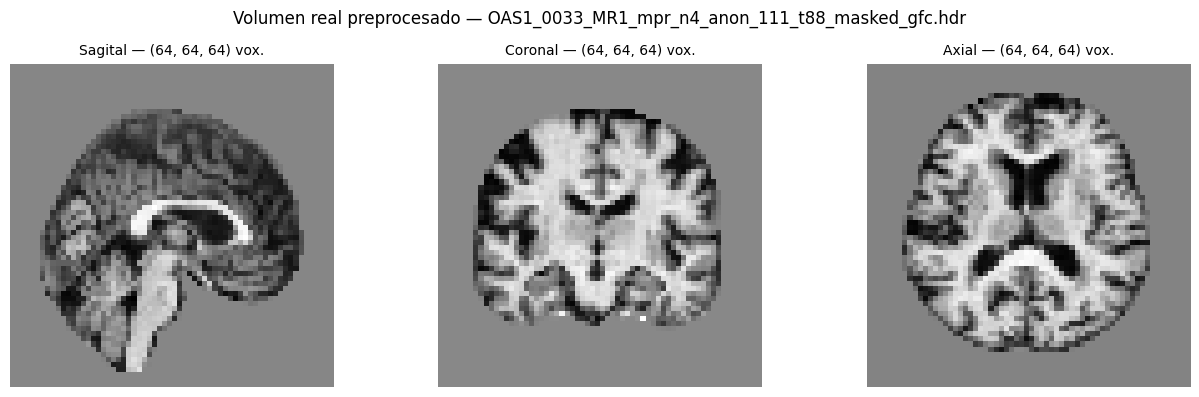

Verificacion completada.


In [ ]:
# seleccionar un real y un sintético del split de entrenamiento
row_real  = df_aug.query("split=='train' and tipo=='real'").iloc[0]
row_synth = df_aug.query("split=='train' and tipo=='synthetic'").iloc[0]

print('Verificando pipeline de preprocesamiento...\n')
for tag, row in [('REAL     ', row_real), ('SINTETICO', row_synth)]:
    vol, lbl = OASIS3DDataset(pd.DataFrame([row]))[0]
    d, h, w  = vol.shape[1], vol.shape[2], vol.shape[3]
    vmin, vmax = vol.min().item(), vol.max().item()
    vmean, vstd = vol.mean().item(), vol.std().item()
    print(f'  [{tag}] label={int(lbl.item())}  shape={tuple(vol.shape)}  '
          f'min={vmin:.3f}  max={vmax:.3f}  mean={vmean:.3f}  std={vstd:.3f}')

# visualización de cortes del volumen real preprocesado
vol_np = load_and_preprocess(row_real['file_path']).squeeze(0).numpy()
cx, cy, cz = [s // 2 for s in vol_np.shape]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle(f'Volumen real preprocesado — {os.path.basename(row_real["file_path"])}',
             fontsize=12)

for ax, sl, title in zip(
    axes,
    [vol_np[cx, :, :], vol_np[:, cy, :], vol_np[:, :, cz]],
    ['Sagital', 'Coronal', 'Axial']
):
    ax.imshow(sl.T, cmap='gray', origin='lower')
    ax.set_title(f'{title} — {TARGET_SHAPE} vox.', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sample_preprocessed_3D.png'),
            dpi=100, bbox_inches='tight')
plt.show()
print('Verificacion completada.')

los volúmenes se redimensionaron de 176×208×176 vóxeles originales a 64×64×64

### Construir dataframes para los tres escenarios de entrenamiento

In [ ]:

df_val  = df_aug[df_aug['split'] == 'val'].copy()
df_test = df_aug[df_aug['split'] == 'test'].copy()

df_val  = df_val[df_val['tipo']  == 'real'].copy()
df_test = df_test[df_test['tipo'] == 'real'].copy()


#  Escenario 1 y 2: solo reales en train
df_train_real = df_aug[
    (df_aug['split'] == 'train') & (df_aug['tipo'] == 'real')
].copy()

#  Escenario 3: reales + sintéticos en train
df_train_hagan = df_aug[df_aug['split'] == 'train'].copy()

SCENARIOS = {
    'baseline_real':   {'train_df': df_train_real,  'aug_mode': 'none'},
    'traditional_aug': {'train_df': df_train_real,  'aug_mode': 'traditional'},
    'hagan_aug':       {'train_df': df_train_hagan, 'aug_mode': 'none'},
}

print(f'{"Escenario":<20} | {"Train":>6} | {"Val":>5} | {"Test":>5} | Aug mode')
print('-' * 60)
for name, cfg in SCENARIOS.items():
    n_tr = len(cfg['train_df'])
    print(f'{name:<20} | {n_tr:>6} | {len(df_val):>5} | {len(df_test):>5} | {cfg["aug_mode"]}')

print('\nDistribución baseline train (reales):')
display(df_train_real.groupby(['label', 'tipo']).size().unstack(fill_value=0))

print('\nDistribución hagan_aug train (reales + sintéticos):')
display(df_train_hagan.groupby(['label', 'tipo']).size().unstack(fill_value=0))

print('\nVal / Test (siempre reales):')
display(df_aug[df_aug['split'].isin(['val','test'])].groupby(['split','label']).size().unstack(fill_value=0))

Escenario            |  Train |   Val |  Test | Aug mode
------------------------------------------------------------
baseline_real        |    143 |    31 |    31 | none
traditional_aug      |    143 |    31 |    31 | traditional
hagan_aug            |    188 |    31 |    31 | none

Distribución baseline train (reales):


tipo,real
label,
sano,94
vmd,49



Distribución hagan_aug train (reales + sintéticos):


tipo,real,synthetic
label,,
sano,94,0
vmd,49,45



Val / Test (siempre reales):


label,sano,vmd
split,,
test,21,10
val,20,11


  ## 3. DataLoaders

  Se crean tres objetos `DataLoader` a partir de las particiones del CSV:

  - **`train_loader`**: incluye los 188 volúmenes de entrenamiento (94 sano + 49 real + 45 VMD sintético). Se activa `shuffle=True` para evitar que el modelo aprenda el orden de presentación de las clases.
  - **`val_loader`**: 31 sujetos reales (20 sano + 11 VMD). Se usa durante el entrenamiento para *early stopping* y búsqueda del umbral óptimo. Sin mezcla.
  - **`test_loader`**: 31 sujetos reales (21 sano + 10 VMD). Sólo se accede al final, una vez fijado el umbral sobre validación.



In [ ]:

NUM_WORKERS = 0 if torch.cuda.is_available() else 2

loader_kwargs = dict(
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker if NUM_WORKERS > 0 else None,
)

def create_dataloaders_3d(train_df, aug_mode='none', batch_size=BATCH_SIZE):

    train_ds = OASIS3DDataset(train_df, augmentation_mode=aug_mode)
    val_ds   = OASIS3DDataset(df_val,   augmentation_mode='none')
    test_ds  = OASIS3DDataset(df_test,  augmentation_mode='none')

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True, generator=g_seed, **loader_kwargs)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size,
                              shuffle=False, **loader_kwargs)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size,
                              shuffle=False, **loader_kwargs)

    print(f'  Train: {len(train_ds)} vols ({len(train_loader)} batches) | '
          f'aug={aug_mode}')
    print(f'  Val  : {len(val_ds)} vols  | Test: {len(test_ds)} vols')
    return train_loader, val_loader, test_loader


print(f'num_workers = {NUM_WORKERS}  (0 en Colab+CUDA para evitar fork error)')
print('Creando DataLoaders...')
loaders = {}
for scenario_name, cfg in SCENARIOS.items():
    print(f'\n[{scenario_name}]')
    loaders[scenario_name] = create_dataloaders_3d(
        train_df=cfg['train_df'],
        aug_mode=cfg['aug_mode'],
        batch_size=BATCH_SIZE
    )

print('\nDataLoaders creados correctamente.')

X_batch, y_batch = next(iter(loaders['hagan_aug'][0]))
print(f'\nBatch shape: X={tuple(X_batch.shape)}  y={tuple(y_batch.shape)}')
print(f'Rango X: [{X_batch.min():.3f}, {X_batch.max():.3f}]')
assert X_batch.dim() == 5, 'ERROR: el tensor 3D debe tener 5 dimensiones.'
assert X_batch.shape[1] == 1, 'ERROR: el canal debe ser 1.'
print('Verificación de forma 5D correcta.')

num_workers = 0  (0 en Colab+CUDA para evitar fork error)
Creando DataLoaders...

[baseline_real]
  Train: 143 vols (36 batches) | aug=none
  Val  : 31 vols  | Test: 31 vols

[traditional_aug]
  Train: 143 vols (36 batches) | aug=traditional
  Val  : 31 vols  | Test: 31 vols

[hagan_aug]
  Train: 188 vols (47 batches) | aug=none
  Val  : 31 vols  | Test: 31 vols

DataLoaders creados correctamente.

Batch shape: X=(4, 1, 64, 64, 64)  y=(4,)
Rango X: [-2.601, 8.235]
Verificación de forma 5D correcta.


In [ ]:
print('Verificando batches de los tres escenarios...\n')

for scenario_name in SCENARIOS:
    train_loader_s, val_loader_s, test_loader_s = loaders[scenario_name]

    X_tr, y_tr = next(iter(train_loader_s))
    X_vl, y_vl = next(iter(val_loader_s))

    assert X_tr.dim() == 5, f'[{scenario_name}] ERROR: train batch no es 5D.'
    assert X_tr.shape[1] == 1, f'[{scenario_name}] ERROR: canal != 1 en train.'
    assert X_vl.dim() == 5, f'[{scenario_name}] ERROR: val batch no es 5D.'

    mem_mb = X_tr.element_size() * X_tr.nelement() / 1e6
    print(f'[{scenario_name}]')
    print(f'  Train  shape={tuple(X_tr.shape)}  rango=[{X_tr.min():.3f}, {X_tr.max():.3f}]'
          f'  mem_batch={mem_mb:.1f} MB')
    print(f'  Val    shape={tuple(X_vl.shape)}  clases={y_vl.tolist()[:6]}')
    print()

print('Verificación de batches OK.')

Verificando batches de los tres escenarios...

[baseline_real]
  Train  shape=(4, 1, 64, 64, 64)  rango=[-1.993, 15.017]  mem_batch=4.2 MB
  Val    shape=(4, 1, 64, 64, 64)  clases=[1.0, 0.0, 0.0, 0.0]

[traditional_aug]
  Train  shape=(4, 1, 64, 64, 64)  rango=[-2.326, 6.878]  mem_batch=4.2 MB
  Val    shape=(4, 1, 64, 64, 64)  clases=[1.0, 0.0, 0.0, 0.0]

[hagan_aug]
  Train  shape=(4, 1, 64, 64, 64)  rango=[-2.149, 8.799]  mem_batch=4.2 MB
  Val    shape=(4, 1, 64, 64, 64)  clases=[1.0, 0.0, 0.0, 0.0]

Verificación de batches OK.


  ## 4. Arquitecturas 3D-ResNet con Transfer Learning

 Se aplica **Transfer
  Learning** usando pesos preentrenados en imágenes médicas 3D a través de la librería **MONAI**. Concretamente, se cargan los pesos del proyecto **MedicalNet**, que preentrenó variantes de ResNet 3D sobre **23 datasets de imágenes médicas volumétricas** (resonancias magnéticas cerebrales, tomografías de tórax, hígado, próstata, entre otros).


In [ ]:
import subprocess, sys

subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', 'monai>=1.0'],
    check=True
)

import monai
print(f'MONAI version: {monai.__version__}')


MONAI version: 1.5.2


In [ ]:
from monai.networks.nets import resnet18, resnet34

def build_model(model_name):
    """
    Construye un 3D-ResNet con pesos MedicalNet preentrenados MONAI

    """
    common_kwargs = dict(
        pretrained=True,
        spatial_dims=3,
        n_input_channels=1,
        num_classes=400,       # requerido por MedicalNet, se reemplaza abajo
        feed_forward=False,    # backbone devuelve (B, 512) ya pooled
        shortcut_type='A',     #  para MedicalNet ResNet18/34
        bias_downsample=True,
    )

    print(f'  Descargando/cargando pesos MedicalNet para {model_name}...')

    if model_name == 'ResNet18_3D':
        model = resnet18(**common_kwargs)
        in_features = 512
    elif model_name == 'ResNet34_3D':
        model = resnet34(**common_kwargs)
        in_features = 512
    else:
        raise ValueError(f'Modelo no reconocido: {model_name}')

    #  salida (B, 512). Solo se añade Linear(512, 1).
    model.fc = nn.Linear(in_features, 1)
    nn.init.kaiming_normal_(model.fc.weight, mode='fan_out', nonlinearity='relu')
    nn.init.zeros_(model.fc.bias)

    print(f'  Pesos MedicalNet cargados. '
          f'Cabeza FC: Linear({in_features}, 1) — Kaiming init.')
    return model


MODEL_CONFIGS = ['ResNet18_3D', 'ResNet34_3D']
print('build_model definida.')

build_model definida.


  Se instancian ambas arquitecturas para verificar que los pesos se cargan
  correctamente y reportar el número de parámetros entrenables.

In [ ]:
print(f'{"Modelo":<15} | {"Params totales (M)":>18} | {"Params FC":>12} | '
      f'{"Params backbone (M)":>20}')
print('-' * 74)

for model_name in MODEL_CONFIGS:
    m = build_model(model_name)

    total_params    = sum(p.numel() for p in m.parameters()) / 1e6
    fc_params       = sum(p.numel() for p in m.fc.parameters())
    backbone_params = (sum(p.numel() for p in m.parameters()) - fc_params) / 1e6

    print(f'{model_name:<15} | {total_params:>18.2f} | {fc_params:>12,} | '
          f'{backbone_params:>20.2f}')
    del m

if torch.cuda.is_available():
    torch.cuda.empty_cache()
print()
print('FC = nueva capa. Backbone = pesos MedicalNet (23 datasets).')

Modelo          | Params totales (M) |    Params FC |  Params backbone (M)
--------------------------------------------------------------------------
  Descargando/cargando pesos MedicalNet para ResNet18_3D...
  Pesos MedicalNet cargados. Cabeza FC: Linear(512, 1) — Kaiming init.
ResNet18_3D     |              32.99 |          513 |                32.99
  Descargando/cargando pesos MedicalNet para ResNet34_3D...
  Pesos MedicalNet cargados. Cabeza FC: Linear(512, 1) — Kaiming init.
ResNet34_3D     |              63.30 |          513 |                63.30

FC = nueva capa. Backbone = pesos MedicalNet (23 datasets).


  ## 5. Entrenamiento

  Se definen las funciones `train_one_epoch` y `evaluate`

  El protocolo de entrenamiento es:
  - `BCEWithLogitsLoss`, `AdamW`, `ReduceLROnPlateau`, `early stopping`.
  - Precisión mixta (`torch.cuda.amp`) para gestionar el VRAM con volúmenes 3D.
  - El mejor checkpoint se guarda según el **F1-macro en validación**.


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    use_cuda = (device.type == 'cuda')
    if use_cuda:
        torch.cuda.reset_peak_memory_stats(device)

    running_loss = 0.0

    for X, y in loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad()

        if use_cuda and scaler is not None:
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                logits = model(X).squeeze(1)
                loss   = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(X).squeeze(1)
            loss   = criterion(logits, y)
            loss.backward()
            optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader)
    peak_mem = (torch.cuda.max_memory_allocated(device) / 1e9) if use_cuda else 0.0
    return avg_loss, peak_mem

In [ ]:
def evaluate(model, loader, criterion, device, threshold=0.5):
    model.eval()
    use_cuda     = (device.type == 'cuda')
    running_loss = 0.0
    all_logits   = []
    all_labels   = []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            if use_cuda:
                with torch.autocast(device_type='cuda', dtype=torch.float16):
                    logits = model(X).squeeze(1)
                    loss   = criterion(logits, y)
            else:
                logits = model(X).squeeze(1)
                loss   = criterion(logits, y)

            running_loss += loss.item()
            all_logits.extend(logits.detach().cpu().float().numpy())
            all_labels.extend(y.detach().cpu().numpy())

    all_logits = np.array(all_logits, dtype=np.float32)
    all_labels = np.array(all_labels, dtype=int)
    all_probs  = torch.sigmoid(torch.tensor(all_logits)).numpy()
    all_preds  = (all_probs >= threshold).astype(int)
    n_unique   = len(np.unique(all_labels))

    return {
        'loss':          running_loss / len(loader),
        'accuracy':      accuracy_score(all_labels, all_preds),
        'f1_macro':      f1_score(all_labels, all_preds, average='macro', zero_division=0),
        'balanced_acc':  balanced_accuracy_score(all_labels, all_preds),
        'recall_vmd':    recall_score(all_labels, all_preds, pos_label=1, zero_division=0),
        'precision_vmd': precision_score(all_labels, all_preds, pos_label=1, zero_division=0),
        'specificity':   recall_score(all_labels, all_preds, pos_label=0, zero_division=0),
        'roc_auc':       roc_auc_score(all_labels, all_probs) if n_unique > 1 else 0.5,
        'mcc':           matthews_corrcoef(all_labels, all_preds),
        'probs':         all_probs,
        'preds':         all_preds,
        'labels':        all_labels,
    }

Función para encontrar umbral óptimo sobre validación

In [ ]:
def find_optimal_threshold(probs, labels, threshold_grid=THRESHOLD_GRID):
    """
    Busca el umbral que maximiza F1-macro con la restricción de que
    recall VMD >= 0.5. Si ningún umbral cumple la restricción,
     pasos de 0.1 hasta encontrar alguno válido.
    """
    min_rec = 0.5
    while min_rec >= 0.0:
        best_thresh, best_f1 = 0.5, -1.0
        for thresh in threshold_grid:
            preds_t   = (probs >= thresh).astype(int)
            recall_t  = recall_score(labels, preds_t,
                                     pos_label=1, zero_division=0)
            if recall_t < min_rec:
                continue
            f1_t = f1_score(labels, preds_t,
                            average='macro', zero_division=0)
            if f1_t > best_f1:
                best_f1     = f1_t
                best_thresh = float(thresh)
        if best_f1 > -1.0:
            return best_thresh, best_f1
        min_rec = round(min_rec - 0.1, 1)   #  si ningún umbral cumple

    best_thresh, best_f1 = 0.5, -1.0
    for thresh in threshold_grid:
        preds_t = (probs >= thresh).astype(int)
        f1_t    = f1_score(labels, preds_t, average='macro', zero_division=0)
        if f1_t > best_f1:
            best_f1, best_thresh = f1_t, float(thresh)
    return best_thresh, best_f1


def plot_training_history_3d(history_df, title='Historial de entrenamiento'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history_df['epoch'], history_df['train_loss'], label='Train loss')
    axes[0].plot(history_df['epoch'], history_df['val_loss'],   label='Val loss')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} — Loss')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history_df['epoch'], history_df['val_f1_macro'],
                 label='Val F1-macro (umbral con restricción recall≥0.5)')
    axes[1].plot(history_df['epoch'], history_df['val_balanced_acc'],
                 label='Val Balanced Acc')
    axes[1].plot(history_df['epoch'], history_df['val_recall_vmd'],
                 label='Val Recall VMD')
    axes[1].plot(history_df['epoch'], history_df['val_roc_auc'],
                 label='Val ROC-AUC')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Score')
    axes[1].set_title(f'{title} — Métricas')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    save_name = title.replace(' ', '_').replace('|', '').replace('—', '').strip()
    fig_path  = os.path.join(RESULTS_DIR, f'history_{save_name}.png')
    plt.savefig(fig_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Guardado: {fig_path}')

In [ ]:
FREEZE_EPOCHS = 5

all_histories    = {}
all_results      = {}
boot_val_results = {}
test_results     = {}


def bootstrap_metrics(labels, probs, threshold, n_boot=1000, ci=95, seed=42):
    rng    = np.random.default_rng(seed)
    labels = np.array(labels)
    probs  = np.array(probs)
    boot   = {'f1_macro': [], 'recall_vmd': [], 'bal_acc': [], 'roc_auc': []}
    alpha  = (100 - ci) / 2

    for _ in range(n_boot):
        idx = rng.integers(0, len(labels), size=len(labels))
        lb, prb = labels[idx], probs[idx]
        pb = (prb >= threshold).astype(int)
        if len(np.unique(lb)) < 2:
            continue
        boot['f1_macro'].append(f1_score(lb, pb, average='macro', zero_division=0))
        boot['recall_vmd'].append(recall_score(lb, pb, pos_label=1, zero_division=0))
        boot['bal_acc'].append(balanced_accuracy_score(lb, pb))
        boot['roc_auc'].append(roc_auc_score(lb, prb))

    result = {}
    for k, v in boot.items():
        arr = np.array(v)
        result[k] = {
            'mean':  float(arr.mean()),
            'lower': float(np.percentile(arr, alpha)),
            'upper': float(np.percentile(arr, 100 - alpha)),
        }
    return result


def train_single_model(model_name, scenario_name, force_retrain=True):
    run_key   = (model_name, scenario_name)
    ckpt_path = os.path.join(CKPT_DIR,    f'{model_name}_{scenario_name}_best.pth')
    hist_path = os.path.join(RESULTS_DIR, f'history_{model_name}_{scenario_name}.csv')

    if os.path.exists(ckpt_path) and os.path.exists(hist_path) and not force_retrain:
        ckpt    = torch.load(ckpt_path, map_location='cpu', weights_only=False)
        hist_df = pd.read_csv(hist_path)

        model = build_model(model_name).to(device)
        model.load_state_dict(ckpt['model_state_dict'])
        model.eval()
        criterion_tmp = nn.BCEWithLogitsLoss()
        _, val_loader_s, _ = loaders[scenario_name]
        val_raw = evaluate(model, val_loader_s, criterion_tmp, device, threshold=0.5)
        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        result = {
            'model_name':         model_name,
            'scenario_name':      scenario_name,
            'n_params_M':         ckpt.get('n_params_M', 0.0),
            'total_time_min':     float(hist_df['epoch_time_s'].sum()) / 60,
            'mean_epoch_time_s':  float(hist_df['epoch_time_s'].mean()),
            'peak_gpu_mem_gb':    float(hist_df['peak_gpu_mem_gb'].max()),
            'best_val_f1':        ckpt.get('best_val_f1', float('nan')),
            'best_val_threshold': ckpt.get('best_val_threshold', 0.5),
            'epochs_trained':     len(hist_df),
            'ckpt_path':          ckpt_path,
            'val_probs':          val_raw['probs'],
            'val_labels':         val_raw['labels'],
        }
        all_histories[run_key] = hist_df
        all_results[run_key]   = result
        plot_training_history_3d(hist_df, title=f'{model_name} | {scenario_name}')
        return result, hist_df

    train_loader_s, val_loader_s, _ = loaders[scenario_name]

    print(f'\n{"=" * 70}')
    print(f'  ENTRENANDO: {model_name}  |  Escenario: {scenario_name}')
    print(f'{"=" * 70}')

    model = build_model(model_name).to(device)

    train_df_scenario = SCENARIOS[scenario_name]['train_df']
    n_sano = (train_df_scenario['label'] == 'sano').sum()
    n_vmd  = (train_df_scenario['label'] == 'vmd').sum()
    if n_sano > n_vmd:
        pw_value = n_sano / n_vmd
        pos_weight_tensor = torch.tensor([pw_value]).to(device)
        print(f'  pos_weight      : {pw_value:.2f}  (sano={n_sano}, vmd={n_vmd})')
    else:
        pos_weight_tensor = None
        print(f'  pos_weight      : None  (balanceado: sano={n_sano}, vmd={n_vmd})')

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=PATIENCE_SCH, factor=0.5
    )

    use_cuda = (device.type == 'cuda')
    if use_cuda:
        try:
            scaler = torch.amp.GradScaler('cuda')
        except TypeError:
            scaler = torch.cuda.amp.GradScaler()
    else:
        scaler = None

    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f'  Parametros      : {n_params:.2f} M')
    print(f'  Checkpoint      : {ckpt_path}')
    print(f'  FREEZE_EPOCHS   : {FREEZE_EPOCHS}')

    if FREEZE_EPOCHS > 0:
        for pname, param in model.named_parameters():
            if 'fc' not in pname:
                param.requires_grad = False
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'  Backbone congelado {FREEZE_EPOCHS} epocas. Entrenables: {trainable:,}')

    history = {k: [] for k in [
        'epoch', 'train_loss', 'val_loss',
        'val_f1_macro', 'val_balanced_acc', 'val_recall_vmd',
        'val_roc_auc', 'val_opt_threshold',
        'lr', 'epoch_time_s', 'peak_gpu_mem_gb'
    ]}

    best_val_f1       = -1.0
    best_thresh_saved = 0.5
    best_val_probs    = None
    best_val_labels   = None
    patience_ctr      = 0
    t_total_0         = time.time()

    for epoch in range(1, MAX_EPOCHS + 1):

        if FREEZE_EPOCHS > 0 and epoch == FREEZE_EPOCHS + 1:
            for param in model.parameters():
                param.requires_grad = True
            print(f'  E{epoch}: Backbone descongelado. Fine-tuning completo.')

        t0 = time.time()
        train_loss, peak_mem = train_one_epoch(
            model, train_loader_s, optimizer, criterion, scaler, device
        )
        val_raw = evaluate(model, val_loader_s, criterion, device, threshold=0.5)
        epoch_thresh, epoch_f1_val = find_optimal_threshold(
            val_raw['probs'], val_raw['labels']
        )
        epoch_time = time.time() - t0
        current_lr = optimizer.param_groups[0]['lr']

        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_raw['loss'])
        history['val_f1_macro'].append(epoch_f1_val)
        history['val_balanced_acc'].append(val_raw['balanced_acc'])
        history['val_recall_vmd'].append(val_raw['recall_vmd'])
        history['val_roc_auc'].append(val_raw['roc_auc'])
        history['val_opt_threshold'].append(epoch_thresh)
        history['lr'].append(current_lr)
        history['epoch_time_s'].append(epoch_time)
        history['peak_gpu_mem_gb'].append(peak_mem)

        scheduler.step(epoch_f1_val)

        if epoch_f1_val > best_val_f1:
            best_val_f1       = epoch_f1_val
            best_thresh_saved = epoch_thresh
            best_val_probs    = val_raw['probs'].copy()
            best_val_labels   = val_raw['labels'].copy()
            patience_ctr      = 0
            torch.save({
                'model_state_dict':   model.state_dict(),
                'model_name':         model_name,
                'scenario_name':      scenario_name,
                'epoch':              epoch,
                'best_val_f1':        best_val_f1,
                'best_val_threshold': best_thresh_saved,
                'n_params_M':         n_params,
            }, ckpt_path)
            flag = ' <- MEJOR'
        else:
            patience_ctr += 1
            flag = ''

        if epoch % 5 == 0 or epoch == 1 or flag:
            print(
                f'  E{epoch:3d}/{MAX_EPOCHS} | '
                f'L_tr={train_loss:.4f}  L_val={val_raw["loss"]:.4f} | '
                f'Thr={epoch_thresh:.2f}  F1={epoch_f1_val:.4f}  '
                f'RecVMD={val_raw["recall_vmd"]:.4f}  '
                f'AUC={val_raw["roc_auc"]:.4f} | '
                f't={epoch_time:.1f}s  GPU={peak_mem:.2f}GB{flag}'
            )

        if patience_ctr >= PATIENCE_ES:
            print(f'\n  Early stopping en epoca {epoch}. '
                  f'Mejor val F1-macro: {best_val_f1:.4f}')
            break

    total_time = time.time() - t_total_0
    history_df = pd.DataFrame(history)
    history_df.to_csv(hist_path, index=False)

    result = {
        'model_name':         model_name,
        'scenario_name':      scenario_name,
        'n_params_M':         n_params,
        'total_time_min':     total_time / 60,
        'mean_epoch_time_s':  float(history_df['epoch_time_s'].mean()),
        'peak_gpu_mem_gb':    float(history_df['peak_gpu_mem_gb'].max()),
        'best_val_f1':        best_val_f1,
        'best_val_threshold': best_thresh_saved,
        'epochs_trained':     len(history_df),
        'ckpt_path':          ckpt_path,
        'val_probs':          best_val_probs,
        'val_labels':         best_val_labels,
    }
    all_histories[run_key] = history_df
    all_results[run_key]   = result

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(f'\n{"─" * 70}')
    print(f'  ✓ {model_name} | {scenario_name}')
    print(f'    Epocas entrenadas  : {len(history_df)}')
    print(f'    Mejor Val F1-macro : {best_val_f1:.4f}')
    print(f'    Umbral optimo (val): {best_thresh_saved:.2f}')
    print(f'    Tiempo total       : {total_time/60:.1f} min')
    print(f'    Checkpoint guardado: {ckpt_path}')
    print(f'{"─" * 70}')

    plot_training_history_3d(history_df, title=f'{model_name} | {scenario_name}')
    return result, history_df


print(f'Funciones definidas. FREEZE_EPOCHS={FREEZE_EPOCHS}.')

Funciones definidas. FREEZE_EPOCHS=5.


  EXPERIMENTOS — 6 runs | FREEZE_EPOCHS=5

  ResNet18_3D | baseline_real

  ENTRENANDO: ResNet18_3D  |  Escenario: baseline_real
  Descargando/cargando pesos MedicalNet para ResNet18_3D...
  Pesos MedicalNet cargados. Cabeza FC: Linear(512, 1) — Kaiming init.
  pos_weight      : 1.92  (sano=94, vmd=49)
  Parametros      : 32.99 M
  Checkpoint      : /content/drive/MyDrive/Proyecto imagenes y vision/Models/Modelo_3D_results/checkpoints/ResNet18_3D_baseline_real_best.pth
  FREEZE_EPOCHS   : 5
  Backbone congelado 5 epocas. Entrenables: 513
  E  1/50 | L_tr=17.2872  L_val=15.3310 | Thr=0.10  F1=0.3922  RecVMD=0.0000  AUC=0.3318 | t=72.4s  GPU=1.50GB <- MEJOR
  E  5/50 | L_tr=14.6341  L_val=20.2665 | Thr=0.10  F1=0.3922  RecVMD=0.0000  AUC=0.4636 | t=46.7s  GPU=1.50GB
  E6: Backbone descongelado. Fine-tuning completo.
  E 10/50 | L_tr=2.4822  L_val=33.1537 | Thr=0.10  F1=0.3922  RecVMD=0.0000  AUC=0.7545 | t=46.8s  GPU=2.17GB

  Early stopping en epoca 11. Mejor val F1-macro: 0.3922

─────

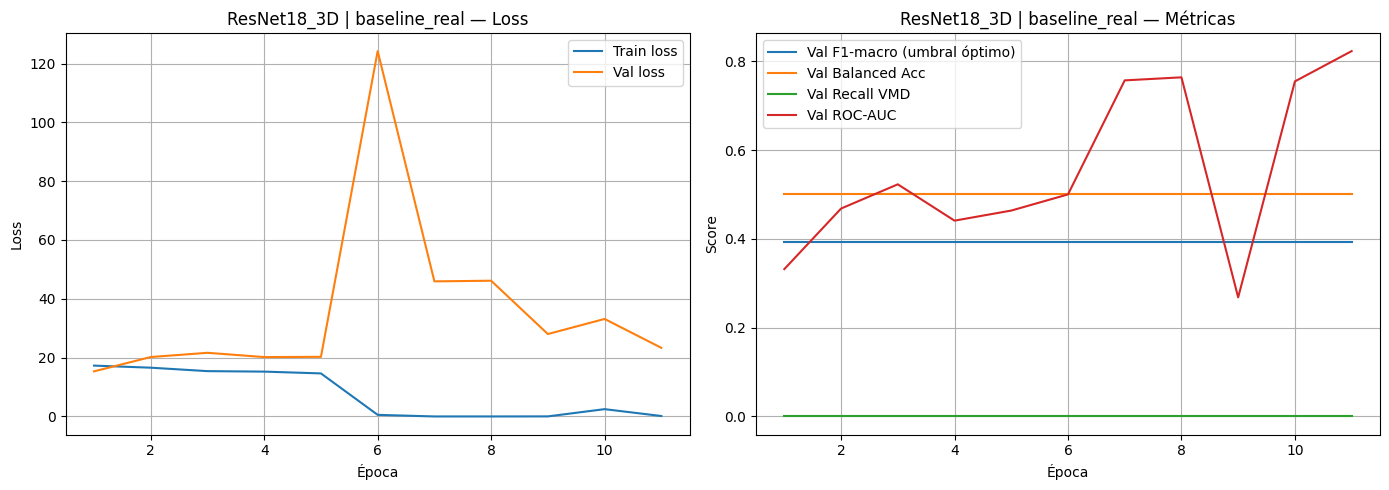

Guardado: /content/drive/MyDrive/Proyecto imagenes y vision/Models/Modelo_3D_results/history_ResNet18_3D__baseline_real.png

  ResNet18_3D | traditional_aug

  ENTRENANDO: ResNet18_3D  |  Escenario: traditional_aug
  Descargando/cargando pesos MedicalNet para ResNet18_3D...
  Pesos MedicalNet cargados. Cabeza FC: Linear(512, 1) — Kaiming init.
  pos_weight      : 1.92  (sano=94, vmd=49)
  Parametros      : 32.99 M
  Checkpoint      : /content/drive/MyDrive/Proyecto imagenes y vision/Models/Modelo_3D_results/checkpoints/ResNet18_3D_traditional_aug_best.pth
  FREEZE_EPOCHS   : 5
  Backbone congelado 5 epocas. Entrenables: 513
  E  1/50 | L_tr=5.1248  L_val=13.5192 | Thr=0.10  F1=0.2619  RecVMD=1.0000  AUC=0.5000 | t=48.1s  GPU=1.77GB <- MEJOR
  E  2/50 | L_tr=2.8571  L_val=26.1454 | Thr=0.10  F1=0.4038  RecVMD=0.8182  AUC=0.4000 | t=53.0s  GPU=1.77GB <- MEJOR
  E  5/50 | L_tr=3.2069  L_val=29.7405 | Thr=0.10  F1=0.3845  RecVMD=0.6364  AUC=0.4091 | t=45.5s  GPU=1.77GB
  E6: Backbone desco

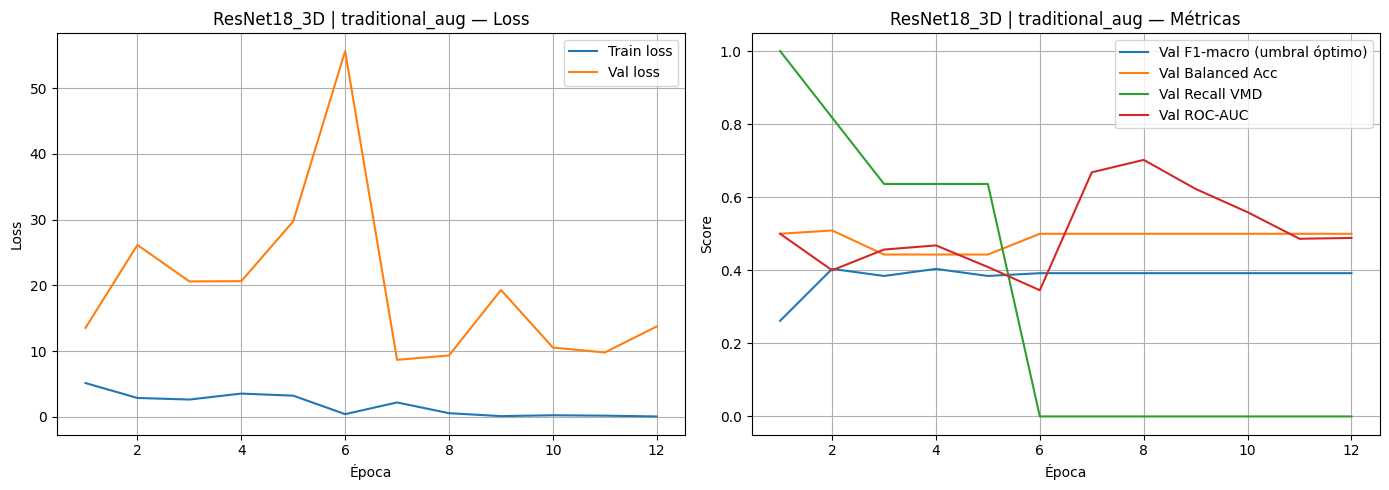

Guardado: /content/drive/MyDrive/Proyecto imagenes y vision/Models/Modelo_3D_results/history_ResNet18_3D__traditional_aug.png

  ResNet18_3D | hagan_aug

  ENTRENANDO: ResNet18_3D  |  Escenario: hagan_aug
  Descargando/cargando pesos MedicalNet para ResNet18_3D...
  Pesos MedicalNet cargados. Cabeza FC: Linear(512, 1) — Kaiming init.
  pos_weight      : None  (balanceado: sano=94, vmd=94)
  Parametros      : 32.99 M
  Checkpoint      : /content/drive/MyDrive/Proyecto imagenes y vision/Models/Modelo_3D_results/checkpoints/ResNet18_3D_hagan_aug_best.pth
  FREEZE_EPOCHS   : 5
  Backbone congelado 5 epocas. Entrenables: 513
  E  1/50 | L_tr=8.9334  L_val=1.5280 | Thr=0.10  F1=0.4833  RecVMD=0.0909  AUC=0.7864 | t=81.3s  GPU=2.04GB <- MEJOR
  E  2/50 | L_tr=9.0097  L_val=13.5098 | Thr=0.85  F1=0.5479  RecVMD=0.7273  AUC=0.5909 | t=82.1s  GPU=2.04GB <- MEJOR
  E  3/50 | L_tr=8.7285  L_val=4.2536 | Thr=0.40  F1=0.6026  RecVMD=0.5455  AUC=0.6000 | t=80.3s  GPU=2.04GB <- MEJOR
  E  4/50 | L_tr=

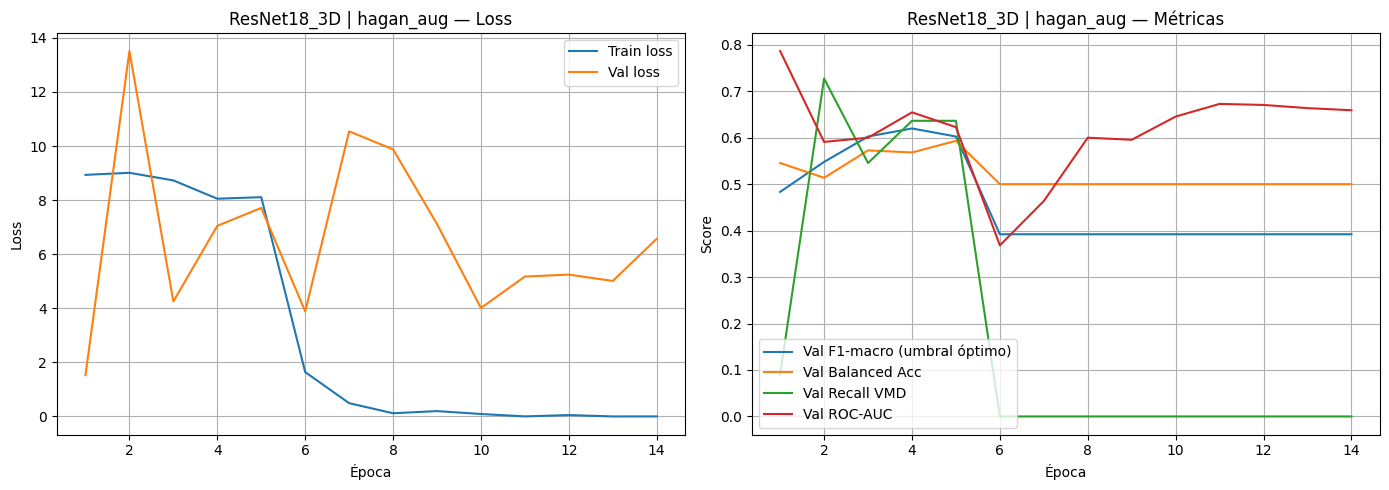

Guardado: /content/drive/MyDrive/Proyecto imagenes y vision/Models/Modelo_3D_results/history_ResNet18_3D__hagan_aug.png

  ResNet34_3D | baseline_real

  ENTRENANDO: ResNet34_3D  |  Escenario: baseline_real
  Descargando/cargando pesos MedicalNet para ResNet34_3D...
  Pesos MedicalNet cargados. Cabeza FC: Linear(512, 1) — Kaiming init.
  pos_weight      : 1.92  (sano=94, vmd=49)
  Parametros      : 63.30 M
  Checkpoint      : /content/drive/MyDrive/Proyecto imagenes y vision/Models/Modelo_3D_results/checkpoints/ResNet34_3D_baseline_real_best.pth
  FREEZE_EPOCHS   : 5
  Backbone congelado 5 epocas. Entrenables: 513
  E  1/50 | L_tr=56.8716  L_val=53.2722 | Thr=0.10  F1=0.3922  RecVMD=0.0000  AUC=0.4568 | t=49.5s  GPU=2.42GB <- MEJOR
  E  5/50 | L_tr=50.7035  L_val=58.5214 | Thr=0.10  F1=0.3922  RecVMD=0.0000  AUC=0.4591 | t=44.9s  GPU=2.42GB
  E6: Backbone descongelado. Fine-tuning completo.
  E 10/50 | L_tr=0.0002  L_val=81.6692 | Thr=0.10  F1=0.3922  RecVMD=0.0000  AUC=0.5000 | t=45.1

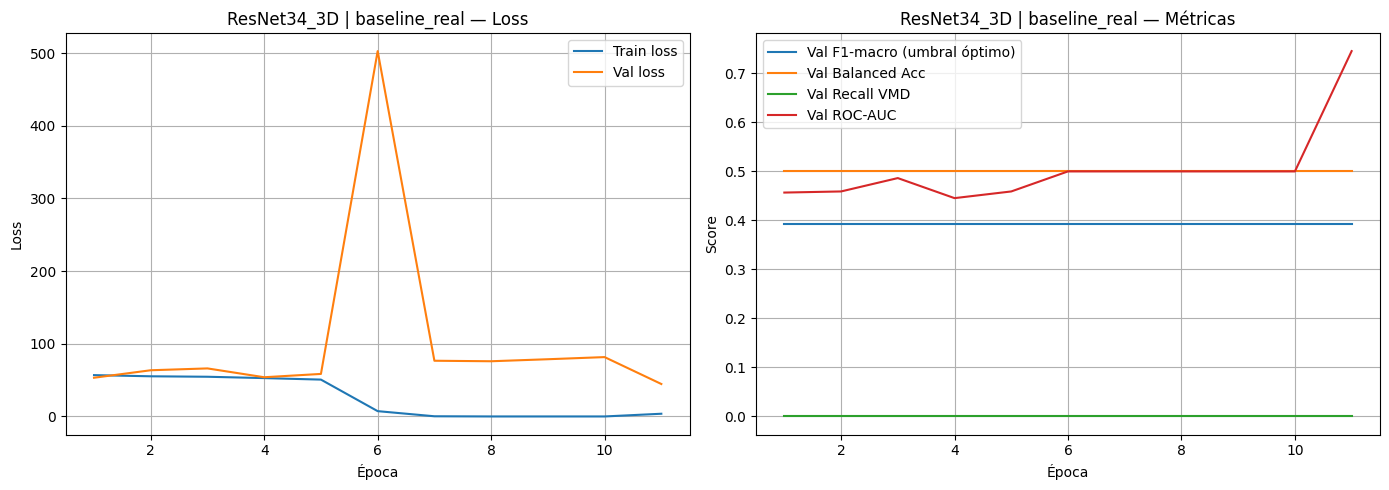

Guardado: /content/drive/MyDrive/Proyecto imagenes y vision/Models/Modelo_3D_results/history_ResNet34_3D__baseline_real.png

  ResNet34_3D | traditional_aug

  ENTRENANDO: ResNet34_3D  |  Escenario: traditional_aug
  Descargando/cargando pesos MedicalNet para ResNet34_3D...
  Pesos MedicalNet cargados. Cabeza FC: Linear(512, 1) — Kaiming init.
  pos_weight      : 1.92  (sano=94, vmd=49)
  Parametros      : 63.30 M
  Checkpoint      : /content/drive/MyDrive/Proyecto imagenes y vision/Models/Modelo_3D_results/checkpoints/ResNet34_3D_traditional_aug_best.pth
  FREEZE_EPOCHS   : 5
  Backbone congelado 5 epocas. Entrenables: 513
  E  1/50 | L_tr=22.1616  L_val=26.1078 | Thr=0.10  F1=0.3922  RecVMD=0.0000  AUC=0.6432 | t=47.9s  GPU=2.94GB <- MEJOR
  E  5/50 | L_tr=16.4941  L_val=23.6855 | Thr=0.10  F1=0.3922  RecVMD=0.0000  AUC=0.4341 | t=50.0s  GPU=2.94GB
  E6: Backbone descongelado. Fine-tuning completo.
  E 10/50 | L_tr=0.3200  L_val=9.1035 | Thr=0.10  F1=0.3922  RecVMD=0.0000  AUC=0.3318

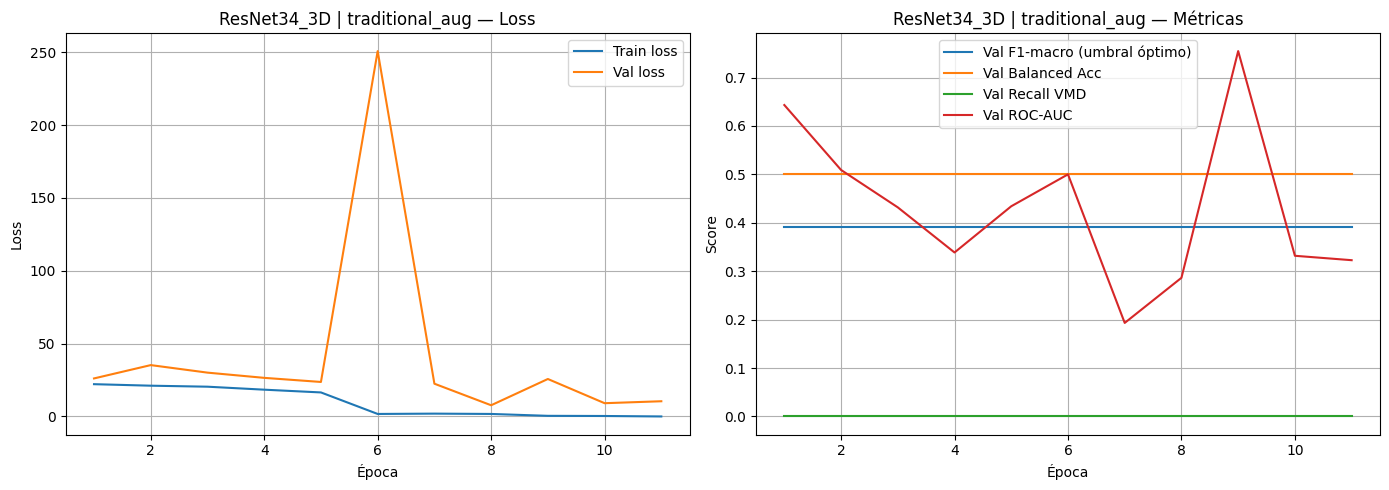

Guardado: /content/drive/MyDrive/Proyecto imagenes y vision/Models/Modelo_3D_results/history_ResNet34_3D__traditional_aug.png

  ResNet34_3D | hagan_aug

  ENTRENANDO: ResNet34_3D  |  Escenario: hagan_aug
  Descargando/cargando pesos MedicalNet para ResNet34_3D...
  Pesos MedicalNet cargados. Cabeza FC: Linear(512, 1) — Kaiming init.
  pos_weight      : None  (balanceado: sano=94, vmd=94)
  Parametros      : 63.30 M
  Checkpoint      : /content/drive/MyDrive/Proyecto imagenes y vision/Models/Modelo_3D_results/checkpoints/ResNet34_3D_hagan_aug_best.pth
  FREEZE_EPOCHS   : 5
  Backbone congelado 5 epocas. Entrenables: 513
  E  1/50 | L_tr=12.0738  L_val=20.2617 | Thr=0.10  F1=0.2619  RecVMD=1.0000  AUC=0.5000 | t=84.1s  GPU=3.45GB <- MEJOR
  E  4/50 | L_tr=6.3311  L_val=2.9313 | Thr=0.90  F1=0.4790  RecVMD=0.7273  AUC=0.4636 | t=91.4s  GPU=3.45GB <- MEJOR
  E  5/50 | L_tr=3.8706  L_val=2.7117 | Thr=0.55  F1=0.5806  RecVMD=0.8182  AUC=0.6727 | t=93.9s  GPU=3.45GB <- MEJOR
  E6: Backbone d

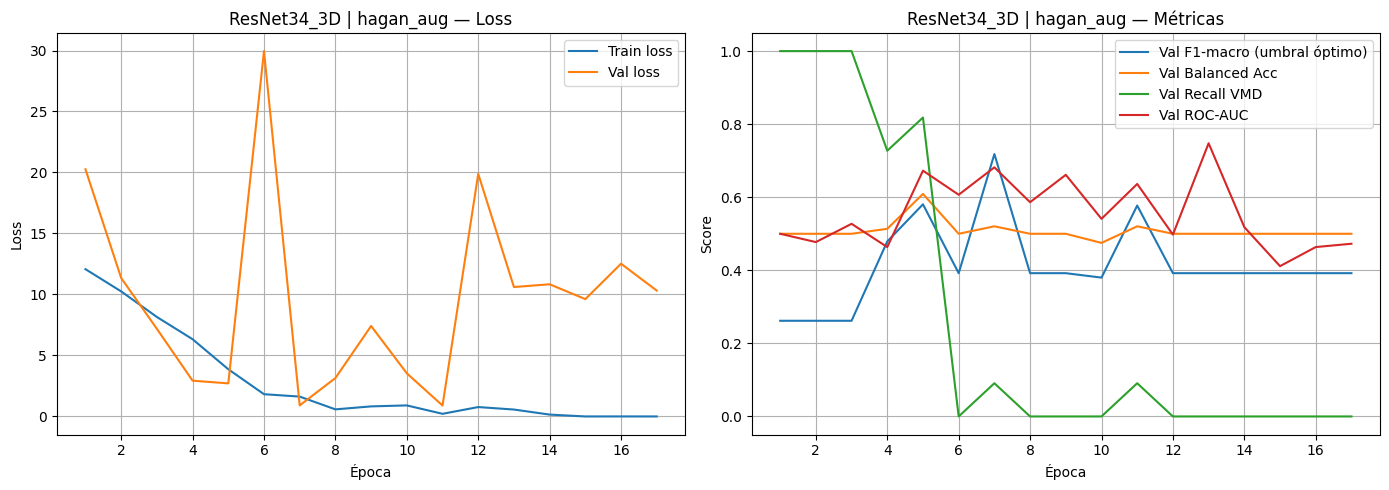

Guardado: /content/drive/MyDrive/Proyecto imagenes y vision/Models/Modelo_3D_results/history_ResNet34_3D__hagan_aug.png

  RESUMEN EXPERIMENTOS — VALIDACION (Val F1-macro puntual)

  Rank  Modelo          Escenario          Val F1-macro  Umbral opt.
  -------------------------------------------------------
  1     ResNet34_3D     hagan_aug                0.7182         0.10  <- MEJOR
  2     ResNet18_3D     hagan_aug                0.6198         0.90
  3     ResNet18_3D     traditional_aug          0.4038         0.10
  4     ResNet18_3D     baseline_real            0.3922         0.10
  5     ResNet34_3D     baseline_real            0.3922         0.10
  6     ResNet34_3D     traditional_aug          0.3922         0.10


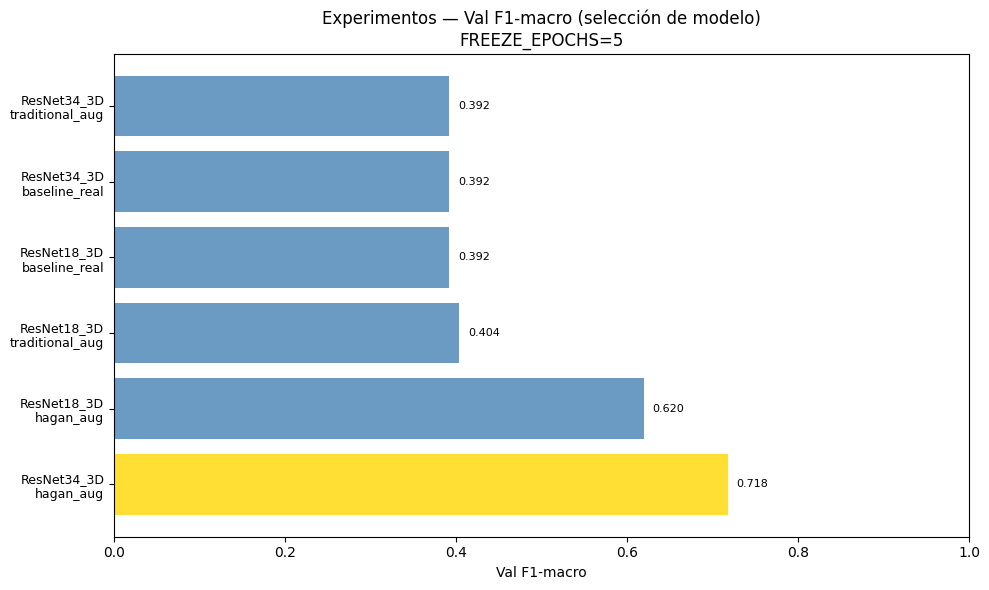


  Mejor modelo para TEST: ResNet34_3D | hagan_aug
  Val F1-macro (puntual): 0.7182


In [ ]:
import matplotlib.gridspec as gridspec

EXPERIMENT_GRID = [
    ('ResNet18_3D', 'baseline_real'),
    ('ResNet18_3D', 'traditional_aug'),
    ('ResNet18_3D', 'hagan_aug'),
    ('ResNet34_3D', 'baseline_real'),
    ('ResNet34_3D', 'traditional_aug'),
    ('ResNet34_3D', 'hagan_aug'),
]

print('=' * 70)
print(f'  EXPERIMENTOS — {len(EXPERIMENT_GRID)} runs | FREEZE_EPOCHS={FREEZE_EPOCHS}')
print('=' * 70)

for model_name, scenario_name in EXPERIMENT_GRID:
    print(f'\n  {model_name} | {scenario_name}')
    train_single_model(model_name, scenario_name, force_retrain=True)

print('\n' + '=' * 70)
print('  RESUMEN EXPERIMENTOS — VALIDACION (Val F1-macro puntual)')
print('=' * 70)

ranking = sorted(
    all_results.items(),
    key=lambda x: x[1]['best_val_f1'],
    reverse=True
)

print(f'\n  {"Rank":<5} {"Modelo":<15} {"Escenario":<18} '
      f'{"Val F1-macro":>12} {"Umbral opt.":>12}')
print(f'  {"-" * 55}')

for rank, ((mn, sn), res) in enumerate(ranking, 1):
    mark = '  <- MEJOR' if rank == 1 else ''
    print(f'  {rank:<5} {mn:<15} {sn:<18} '
          f'{res["best_val_f1"]:>12.4f} '
          f'{res["best_val_threshold"]:>12.2f}{mark}')

pd.DataFrame([{
    'model_name':     mn,
    'scenario_name':  sn,
    'val_f1':         res['best_val_f1'],
    'val_threshold':  res['best_val_threshold'],
    'epochs_trained': res['epochs_trained'],
} for (mn, sn), res in ranking]).to_csv(
    os.path.join(RESULTS_DIR, 'experiments_val_ranking.csv'), index=False)

fig, ax = plt.subplots(figsize=(10, 6))
labels_plot = [f'{mn}\n{sn}' for (mn, sn), _ in ranking]
vals_p = [res['best_val_f1'] for _, res in ranking]
y_pos  = np.arange(len(labels_plot))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(labels_plot))]
ax.barh(y_pos, vals_p, align='center', color=colors, alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels_plot, fontsize=9)
ax.set_xlim(0, 1)
ax.set_xlabel('Val F1-macro')
ax.set_title(f'Experimentos — Val F1-macro (selección de modelo)\nFREEZE_EPOCHS={FREEZE_EPOCHS}')
for i, v in enumerate(vals_p):
    ax.text(min(v + 0.01, 0.99), i, f'{v:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'experiments_val_summary.png'), dpi=150, bbox_inches='tight')
plt.show()

best_key = ranking[0][0]
best_mn, best_sn = best_key
best_res = all_results[best_key]
print(f'\n  Mejor modelo para TEST: {best_mn} | {best_sn}')
print(f'  Val F1-macro (puntual): {best_res["best_val_f1"]:.4f}')

  ## 6. Evaluación en Test

  Se carga el mejor checkpoint de cada modelo reconstruyendo la misma arquitectura MONAI utilizada en el
  entrenamiento.

  - **Umbral óptimo sobre validación**

  - **Evaluación en test con umbral óptimo**


In [ ]:
best_mn, best_sn = best_key
best_res = all_results[best_key]

print('=' * 70)
print(f'  TEST — {best_mn} | {best_sn}')
print(f'  Umbral (val): {best_res["best_val_threshold"]:.2f}')
print(f'  Val F1-macro: {best_res["best_val_f1"]:.4f}')
print('=' * 70)

model_test = build_model(best_mn).to(device)
ckpt_test  = torch.load(best_res['ckpt_path'], map_location=device, weights_only=False)
model_test.load_state_dict(ckpt_test['model_state_dict'])
model_test.eval()
criterion_test = nn.BCEWithLogitsLoss()

_, _, test_loader_s = loaders[best_sn]
test_threshold = best_res['best_val_threshold']
test_raw = evaluate(model_test, test_loader_s, criterion_test, device,
                    threshold=test_threshold)

del model_test
if torch.cuda.is_available():
    torch.cuda.empty_cache()

test_labels = test_raw['labels']
test_probs  = test_raw['probs']
test_preds  = test_raw['preds']

boot_test = bootstrap_metrics(test_labels, test_probs, test_threshold,
                               n_boot=1000, ci=95, seed=0)

print('\n  Metricas TEST (Bootstrap 95% CI, n=1000):')
print(f'  {"Metrica":<18} {"Media":>8} {"IC 95%":>25}')
print(f'  {"-" * 55}')
for k, label in [('f1_macro',   'F1-macro'),
                  ('recall_vmd', 'Recall VMD'),
                  ('bal_acc',    'Balanced Acc'),
                  ('roc_auc',    'ROC-AUC')]:
    m, lo, hi = boot_test[k]['mean'], boot_test[k]['lower'], boot_test[k]['upper']
    print(f'  {label:<18} {m:>8.4f} [{lo:.4f}, {hi:.4f}]')

test_results[best_key] = {
    'model_name':        best_mn,
    'scenario_name':     best_sn,
    'optimal_threshold': test_threshold,
    'f1_macro':          test_raw['f1_macro'],
    'balanced_acc':      test_raw['balanced_acc'],
    'recall_vmd':        test_raw['recall_vmd'],
    'precision_vmd':     test_raw['precision_vmd'],
    'specificity':       test_raw['specificity'],
    'roc_auc':           test_raw['roc_auc'],
    'mcc':               test_raw['mcc'],
    'accuracy':          test_raw['accuracy'],
    'loss':              test_raw['loss'],
    'n_params_M':        best_res['n_params_M'],
    'total_time_min':    best_res['total_time_min'],
    'probs':             test_probs,
    'preds':             test_preds,
    'labels':            test_labels,
    'boot_test':         boot_test,
}

  TEST — ResNet34_3D | hagan_aug
  Umbral (val): 0.10
  Val F1-macro: 0.7182
  Descargando/cargando pesos MedicalNet para ResNet34_3D...
  Pesos MedicalNet cargados. Cabeza FC: Linear(512, 1) — Kaiming init.

  Metricas TEST (Bootstrap 95% CI, n=1000):
  Metrica               Media                    IC 95%
  -------------------------------------------------------
  F1-macro             0.6012 [0.4125, 0.7801]
  Recall VMD           0.5110 [0.2000, 0.8333]
  Balanced Acc         0.6131 [0.4293, 0.7980]
  ROC-AUC              0.6508 [0.4116, 0.8763]


  TP=5  FP=6  FN=5  TN=15
  FN (VMD->Sano): 5 (50.0% del total VMD)


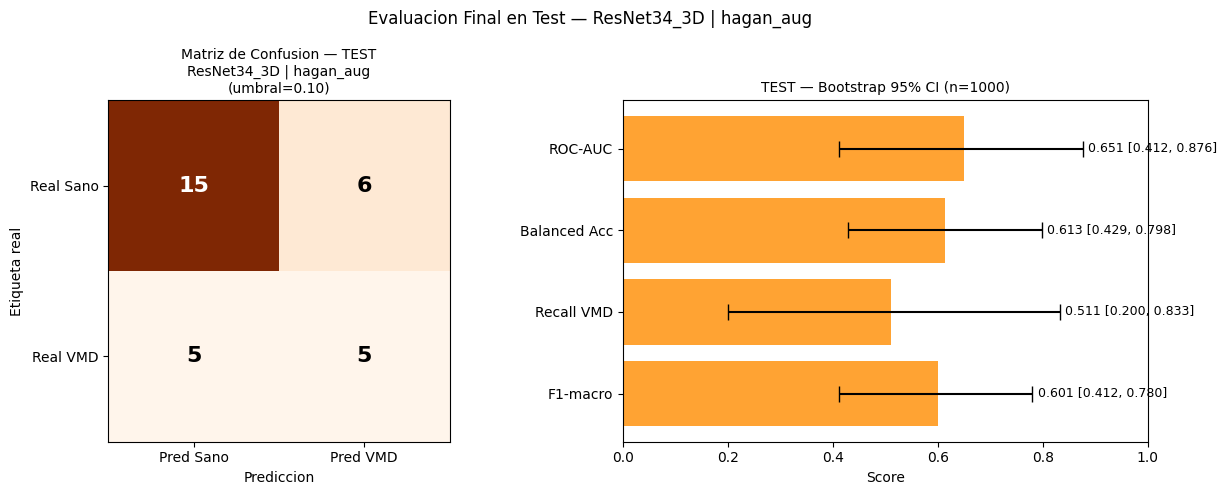

Grafica guardada: /content/drive/MyDrive/Proyecto imagenes y vision/Models/Modelo_3D_results/test_ResNet34_3D_hagan_aug_bootstrap.png


In [ ]:
res_t  = test_results[best_key]
boot_t = res_t['boot_test']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(res_t['labels'], res_t['preds'], labels=[0, 1])
ax = axes[0]
ax.imshow(cm, cmap='Oranges')
ax.set_title(f'Matriz de Confusion — TEST\n{best_mn} | {best_sn}\n'
             f'(umbral={res_t["optimal_threshold"]:.2f})', fontsize=10)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Pred Sano', 'Pred VMD'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['Real Sano', 'Real VMD'])
tc = cm.max() / 2.0
tn, fp, fn, tp_val = cm.ravel()
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > tc else 'black',
                fontsize=16, fontweight='bold')
ax.set_xlabel('Prediccion')
ax.set_ylabel('Etiqueta real')

print(f'  TP={tp_val}  FP={fp}  FN={fn}  TN={tn}')
if (tp_val + fn) > 0:
    print(f'  FN (VMD->Sano): {fn} ({100*fn/(tp_val+fn):.1f}% del total VMD)')

ax2 = axes[1]
metric_keys   = ['f1_macro', 'recall_vmd', 'bal_acc', 'roc_auc']
metric_labels = ['F1-macro', 'Recall VMD', 'Balanced Acc', 'ROC-AUC']
means_t  = [boot_t[k]['mean']  for k in metric_keys]
lowers_t = [boot_t[k]['lower'] for k in metric_keys]
uppers_t = [boot_t[k]['upper'] for k in metric_keys]
errors_t = [[m - l for m, l in zip(means_t, lowers_t)],
            [u - m for m, u in zip(means_t, uppers_t)]]
y_pos = np.arange(len(metric_labels))
ax2.barh(y_pos, means_t, xerr=errors_t, align='center',
         color='darkorange', alpha=0.8, capsize=6)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(metric_labels)
ax2.set_xlim(0, 1)
ax2.set_xlabel('Score')
ax2.set_title('TEST — Bootstrap 95% CI (n=1000)', fontsize=10)
for i, (m, lo, hi) in enumerate(zip(means_t, lowers_t, uppers_t)):
    ax2.text(min(hi + 0.01, 0.99), i,
             f'{m:.3f} [{lo:.3f}, {hi:.3f}]', va='center', fontsize=9)

plt.suptitle(f'Evaluacion Final en Test — {best_mn} | {best_sn}', fontsize=12)
plt.tight_layout()
test_fig_path = os.path.join(RESULTS_DIR, f'test_{best_mn}_{best_sn}_bootstrap.png')
plt.savefig(test_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Grafica guardada: {test_fig_path}')

In [ ]:
res_t  = test_results[best_key]
boot_t = res_t['boot_test']

print('=' * 65)
print('  RESUMEN FINAL — MODELO PARA DESPLIEGUE (3D)')
print('=' * 65)
print(f'  Arquitectura     : {best_mn}')
print(f'  Escenario        : {best_sn}')
print(f'  Checkpoint       : {best_res["ckpt_path"]}')
print(f'  Umbral (val opt) : {res_t["optimal_threshold"]:.2f}')
print(f'  FREEZE_EPOCHS    : {FREEZE_EPOCHS}')
print()
print(f'  {"Metrica":<18} {"Media":>8} {"IC 95%":>25}')
print(f'  {"-" * 55}')
for k, label in [('f1_macro',   'F1-macro'),
                  ('recall_vmd', 'Recall VMD'),
                  ('bal_acc',    'Balanced Acc'),
                  ('roc_auc',    'ROC-AUC')]:
    m, lo, hi = boot_t[k]['mean'], boot_t[k]['lower'], boot_t[k]['upper']
    print(f'  {label:<18} {m:>8.4f} [{lo:.4f}, {hi:.4f}]')

print(f'\n  Especificidad    : {res_t["specificity"]:.4f}')
print(f'  MCC     : {res_t["mcc"]:.4f}')
print(f'  Accuracy  : {res_t["accuracy"]:.4f}')
print(f'  Parametros       : {res_t["n_params_M"]:.2f} M')
print(f'  Tiempo total     : {res_t["total_time_min"]:.1f} min')
print('=' * 65)

deploy_summary = {
    'model_name':        best_mn,
    'scenario_name':     best_sn,
    'ckpt_path':         best_res['ckpt_path'],
    'optimal_threshold': res_t['optimal_threshold'],
    'freeze_epochs':     FREEZE_EPOCHS,
    'val_f1_best':       best_res['best_val_f1'],
    **{f'test_{k}_mean':  boot_t[k]['mean']  for k in ['f1_macro','recall_vmd','bal_acc','roc_auc']},
    **{f'test_{k}_lower': boot_t[k]['lower'] for k in ['f1_macro','recall_vmd','bal_acc','roc_auc']},
    **{f'test_{k}_upper': boot_t[k]['upper'] for k in ['f1_macro','recall_vmd','bal_acc','roc_auc']},
    'test_specificity':  res_t['specificity'],
    'test_mcc':          res_t['mcc'],
    'test_accuracy':     res_t['accuracy'],
    'n_params_M':        res_t['n_params_M'],
    'total_time_min':    res_t['total_time_min'],
}
deploy_path = os.path.join(RESULTS_DIR, 'deploy_model_3d_final.csv')
pd.DataFrame([deploy_summary]).to_csv(deploy_path, index=False)
print(f'\n  CSV guardado: {deploy_path}')

Se re-carga cada checkpoint guardado y re-busca el umbral óptimo sobre VALIDACIÓN usando find_optimal_threshold, se cambio esta funcion pero no se quería volver a entrenar todo, entonces por eso se reevalua en esta celda


In [ ]:
#  RE-EVALUACIÓN COMPLETA CON UMBRAL CORREGIDO
import os, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import (
    f1_score, balanced_accuracy_score, recall_score,
    precision_score, roc_auc_score, matthews_corrcoef,
    accuracy_score, confusion_matrix
)

warnings.filterwarnings('ignore')

REEVAL_GRID = [
    ('ResNet18_3D', 'baseline_real'),
    ('ResNet18_3D', 'traditional_aug'),
    ('ResNet18_3D', 'hagan_aug'),
    ('ResNet34_3D', 'baseline_real'),
    ('ResNet34_3D', 'traditional_aug'),
    ('ResNet34_3D', 'hagan_aug'),
]

def bootstrap_metrics_full(labels, probs, threshold, n_boot=2000, ci=95, seed=42):
    rng    = np.random.default_rng(seed)
    labels = np.array(labels)
    probs  = np.array(probs)
    alpha  = (100 - ci) / 2
    boot   = {k: [] for k in ['f1_macro', 'recall_vmd', 'specificity',
                               'bal_acc', 'roc_auc', 'mcc']}
    for _ in range(n_boot):
        idx = rng.integers(0, len(labels), size=len(labels))
        lb, prb = labels[idx], probs[idx]
        pb = (prb >= threshold).astype(int)
        if len(np.unique(lb)) < 2:
            continue
        boot['f1_macro'].append(
            f1_score(lb, pb, average='macro', zero_division=0))
        boot['recall_vmd'].append(
            recall_score(lb, pb, pos_label=1, zero_division=0))
        boot['specificity'].append(
            recall_score(lb, pb, pos_label=0, zero_division=0))
        boot['bal_acc'].append(balanced_accuracy_score(lb, pb))
        boot['roc_auc'].append(roc_auc_score(lb, prb))
        boot['mcc'].append(matthews_corrcoef(lb, pb))
    result = {}
    for k, v in boot.items():
        arr = np.array(v)
        result[k] = {
            'mean':  float(arr.mean()),
            'lower': float(np.percentile(arr, alpha)),
            'upper': float(np.percentile(arr, 100 - alpha)),
        }
    return result

print('=' * 70)
print('  RE-EVALUACIÓN — Umbral: F1-macro con restricción Recall VMD ≥ 0.5')
print('  (Carga checkpoints guardados, no re-entrena)')
print('=' * 70)

reeval_results = {}

for model_name, scenario_name in REEVAL_GRID:
    run_key   = (model_name, scenario_name)
    ckpt_path = os.path.join(CKPT_DIR, f'{model_name}_{scenario_name}_best.pth')

    if not os.path.exists(ckpt_path):
        print(f'\n  [{model_name} | {scenario_name}] CHECKPOINT NO ENCONTRADO — omitiendo')
        continue

    model_r = build_model(model_name).to(device)
    ckpt_r  = torch.load(ckpt_path, map_location=device, weights_only=False)
    model_r.load_state_dict(ckpt_r['model_state_dict'])
    model_r.eval()
    crit_r = nn.BCEWithLogitsLoss()

    _, val_loader_r, _ = loaders[scenario_name]
    val_raw = evaluate(model_r, val_loader_r, crit_r, device, threshold=0.5)

    thresh, val_f1 = find_optimal_threshold(val_raw['probs'], val_raw['labels'])

    preds_val  = (val_raw['probs'] >= thresh).astype(int)
    val_rec    = recall_score(val_raw['labels'], preds_val, pos_label=1, zero_division=0)
    val_spe    = recall_score(val_raw['labels'], preds_val, pos_label=0, zero_division=0)
    val_ba     = balanced_accuracy_score(val_raw['labels'], preds_val)
    val_auc    = roc_auc_score(val_raw['labels'], val_raw['probs'])
    n_params   = ckpt_r.get('n_params_M', 0.0)

    hist_path = os.path.join(RESULTS_DIR, f'history_{model_name}_{scenario_name}.csv')
    if os.path.exists(hist_path):
        hist_df       = pd.read_csv(hist_path)
        total_min     = float(hist_df['epoch_time_s'].sum()) / 60
        epochs_trained = len(hist_df)
    else:
        total_min, epochs_trained = float('nan'), ckpt_r.get('epoch', '?')

    reeval_results[run_key] = {
        'model_name':     model_name,
        'scenario_name':  scenario_name,
        'threshold':      thresh,
        'val_f1_macro':   val_f1,
        'val_recall_vmd': val_rec,
        'val_specificity':val_spe,
        'val_bal_acc':    val_ba,
        'val_auc':        val_auc,
        'n_params_M':     n_params,
        'total_time_min': total_min,
        'epochs_trained': epochs_trained,
        'ckpt_path':      ckpt_path,
        'val_probs':      val_raw['probs'],
        'val_labels':     val_raw['labels'],
    }

    del model_r
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(f'\n  {model_name} | {scenario_name}')
    print(f'    Umbral (recall≥0.5 → F1-macro) : {thresh:.2f}')
    print(f'    Val F1-macro     : {val_f1:.4f}')
    print(f'    Val Recall VMD   : {val_rec:.4f}')
    print(f'    Val Specificity  : {val_spe:.4f}')
    print(f'    Val Balanced Acc : {val_ba:.4f}')
    print(f'    Val AUC          : {val_auc:.4f}')

print('\n\n' + '=' * 70)
print('  RANKING VALIDACIÓN — F1-macro con restricción Recall VMD ≥ 0.5')
print('=' * 70)
print(f'  {"Rk":<4} {"Modelo":<14} {"Escenario":<17} '
      f'{"Umbral":>7} {"F1-mac":>7} {"RecVMD":>7} '
      f'{"Spe":>6} {"BalAcc":>7} {"AUC":>7}')
print('  ' + '-' * 70)

ranking_r = sorted(reeval_results.items(),
                   key=lambda x: x[1]['val_f1_macro'], reverse=True)

for rank, ((mn, sn), r) in enumerate(ranking_r, 1):
    mark = '  <- MEJOR' if rank == 1 else ''
    print(f'  {rank:<4} {mn:<14} {sn:<17} '
          f'{r["threshold"]:>7.2f} '
          f'{r["val_f1_macro"]:>7.4f} '
          f'{r["val_recall_vmd"]:>7.4f} '
          f'{r["val_specificity"]:>6.4f} '
          f'{r["val_bal_acc"]:>7.4f} '
          f'{r["val_auc"]:>7.4f}{mark}')

print('\n\n  Costo computacional (de históricos guardados):')
print(f'  {"Modelo":<14} {"Escenario":<17} {"Épocas":>7} '
      f'{"T.total":>9} {"Params":>8}')
print('  ' + '-' * 60)
for (mn, sn), r in reeval_results.items():
    print(f'  {mn:<14} {sn:<17} {str(r["epochs_trained"]):>7} '
          f'{r["total_time_min"]:>8.1f}m {r["n_params_M"]:>7.2f}M')

best_key_r          = ranking_r[0][0]
best_mn_r, best_sn_r = best_key_r
best_res_r          = reeval_results[best_key_r]
best_thresh_r       = best_res_r['threshold']

print(f'\n\n  Mejor modelo → TEST : {best_mn_r} | {best_sn_r}')
print(f'  Umbral (val)        : {best_thresh_r:.2f}')
print(f'  Val F1-macro        : {best_res_r["val_f1_macro"]:.4f}')
print(f'  Val Recall VMD      : {best_res_r["val_recall_vmd"]:.4f}')

print('\n' + '=' * 70)
print(f'  TEST — {best_mn_r} | {best_sn_r}  (umbral={best_thresh_r:.2f})')
print('=' * 70)

model_tst = build_model(best_mn_r).to(device)
ckpt_tst  = torch.load(best_res_r['ckpt_path'], map_location=device, weights_only=False)
model_tst.load_state_dict(ckpt_tst['model_state_dict'])
model_tst.eval()
crit_tst = nn.BCEWithLogitsLoss()

_, _, test_loader_r = loaders[best_sn_r]
test_raw = evaluate(model_tst, test_loader_r, crit_tst, device,
                    threshold=best_thresh_r)

del model_tst
if torch.cuda.is_available():
    torch.cuda.empty_cache()

test_labels_r = test_raw['labels']
test_probs_r  = test_raw['probs']
test_preds_r  = test_raw['preds']

boot_r = bootstrap_metrics_full(test_labels_r, test_probs_r, best_thresh_r,
                                 n_boot=2000, ci=95, seed=42)

print('\n  Métricas TEST (Bootstrap 2000 remuestreos, IC 95%):')
print(f'  {"Métrica":<20} {"Media":>8}   IC 95%')
print('  ' + '-' * 55)
for k, label in [('f1_macro',    'F1-macro'),
                  ('recall_vmd',  'Recall VMD'),
                  ('specificity', 'Especificidad'),
                  ('bal_acc',     'Balanced Acc.'),
                  ('roc_auc',     'ROC-AUC'),
                  ('mcc',         'MCC')]:
    m, lo, hi = boot_r[k]['mean'], boot_r[k]['lower'], boot_r[k]['upper']
    print(f'  {label:<20} {m:>8.4f}   [{lo:.4f}, {hi:.4f}]')

cm_r = confusion_matrix(test_labels_r, test_preds_r, labels=[0, 1])
tn_r, fp_r, fn_r, tp_r = cm_r.ravel()
print(f'\n  Accuracy puntual : {accuracy_score(test_labels_r, test_preds_r):.4f}')
print(f'  MCC puntual      : {matthews_corrcoef(test_labels_r, test_preds_r):.4f}')
print(f'  TP={tp_r}  FP={fp_r}  FN={fn_r}  TN={tn_r}')
if (tp_r + fn_r) > 0:
    print(f'  FN (VMD→Sano)    : {fn_r} ({100*fn_r/(tp_r+fn_r):.1f}% del total VMD)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.imshow(cm_r, cmap='Oranges')
ax.set_title(f'Matriz de Confusión — TEST\n{best_mn_r} | {best_sn_r}\n'
             f'umbral={best_thresh_r:.2f}  (F1-mac val con RecVMD≥0.5)',
             fontsize=9)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Pred Sano', 'Pred VMD'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Real Sano', 'Real VMD'])
tc = cm_r.max() / 2.0
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_r[i, j]), ha='center', va='center',
                color='white' if cm_r[i, j] > tc else 'black',
                fontsize=16, fontweight='bold')
ax.set_xlabel('Predicción'); ax.set_ylabel('Etiqueta real')

ax2 = axes[1]
mk   = ['f1_macro', 'recall_vmd', 'specificity', 'bal_acc', 'roc_auc']
mlbl = ['F1-macro', 'Recall VMD', 'Especificidad', 'Balanced Acc.', 'ROC-AUC']
means_r  = [boot_r[k]['mean']  for k in mk]
lowers_r = [boot_r[k]['lower'] for k in mk]
uppers_r = [boot_r[k]['upper'] for k in mk]
errors_r = [[m-l for m, l in zip(means_r, lowers_r)],
            [u-m for m, u in zip(means_r, uppers_r)]]
y_pos = np.arange(len(mlbl))
ax2.barh(y_pos, means_r, xerr=errors_r, align='center',
         color='darkorange', alpha=0.8, capsize=6)
ax2.set_yticks(y_pos); ax2.set_yticklabels(mlbl)
ax2.set_xlim(0, 1); ax2.set_xlabel('Score')
ax2.set_title('TEST — Bootstrap IC 95% (n=2000)\nUmbral: F1-mac val con RecVMD≥0.5',
              fontsize=9)
for i, (m, lo, hi) in enumerate(zip(means_r, lowers_r, uppers_r)):
    ax2.text(min(hi + 0.01, 0.99), i,
             f'{m:.3f} [{lo:.3f}, {hi:.3f}]', va='center', fontsize=8)

plt.suptitle(f'Evaluación Final en Test — {best_mn_r} | {best_sn_r}', fontsize=11)
plt.tight_layout()
fig_path_r = os.path.join(RESULTS_DIR,
                           f'test_{best_mn_r}_{best_sn_r}_corrected.png')
plt.savefig(fig_path_r, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nGráfica guardada: {fig_path_r}')

deploy_r = {
    'model_name':            best_mn_r,
    'scenario_name':         best_sn_r,
    'threshold_criterion':   'F1-macro_val_with_RecallVMD>=0.5',
    'optimal_threshold':     best_thresh_r,
    **{f'test_{k}_mean':  boot_r[k]['mean']  for k in
       ['f1_macro','recall_vmd','specificity','bal_acc','roc_auc','mcc']},
    **{f'test_{k}_lower': boot_r[k]['lower'] for k in
       ['f1_macro','recall_vmd','specificity','bal_acc','roc_auc','mcc']},
    **{f'test_{k}_upper': boot_r[k]['upper'] for k in
       ['f1_macro','recall_vmd','specificity','bal_acc','roc_auc','mcc']},
    'test_accuracy':  accuracy_score(test_labels_r, test_preds_r),
    'test_mcc':       matthews_corrcoef(test_labels_r, test_preds_r),
    'n_params_M':     best_res_r['n_params_M'],
    'total_time_min': best_res_r['total_time_min'],
    'epochs_trained': best_res_r['epochs_trained'],
}
csv_path_r = os.path.join(RESULTS_DIR, 'deploy_model_3d_corrected.csv')
pd.DataFrame([deploy_r]).to_csv(csv_path_r, index=False)
print(f'CSV guardado: {csv_path_r}')